In [77]:
pip install pandas numpy matplotlib seaborn


[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [78]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [79]:
df = pd.read_csv("survey_results_public.csv")
df.head()

,Respondent,Professional,ProgramHobby,Country,University,EmploymentStatus,FormalEducation,MajorUndergrad,HomeRemote,CompanySize,...,StackOverflowMakeMoney,Gender,HighestEducationParents,Race,SurveyLong,QuestionsInteresting,QuestionsConfusing,InterestedAnswers,Salary,ExpectedSalary
0,1,Student,"Yes, both",United States,No,"Not employed, and not looking for work",Secondary school,NaN,NaN,NaN,...,Strongly disagree,Male,High school,White or of European descent,Strongly disagree,Strongly agree,Disagree,Strongly agree,NaN,NaN
1,2,Student,"Yes, both",United Kingdom,"Yes, full-time",Employed part-time,Some college/university study without earning ...,Computer science or software engineering,"More than half, but not all, the time",20 to 99 employees,...,Strongly disagree,Male,A master's degree,White or of European descent,Somewhat agree,Somewhat agree,Disagree,Strongly agree,NaN,37500.0
2,3,Professional developer,"Yes, both",United Kingdom,No,Employed full-time,Bachelor's degree,Computer science or software engineering,"Less than half the time, but at least one day ...","10,000 or more employees",...,Disagree,Male,A professional degree,White or of European descent,Somewhat agree,Agree,Disagree,Agree,113750.0,NaN
3,4,Professional non-developer who sometimes write...,"Yes, both",United States,No,Employed full-time,Doctoral degree,A non-computer-focused engineering discipline,"Less than half the time, but at least one day ...","10,000 or more employees",...,Disagree,Male,A doctoral degree,White or of European descent,Agree,Agree,Somewhat agree,Strongly agree,NaN,NaN
4,5,Professional developer,"Yes, I program as a hobby",Switzerland,No,Employed full-time,Master's degree,Computer science or software engineering,Never,10 to 19 employees,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [80]:
pd.set_option('display.max_rows', None)

col_df = pd.DataFrame({
    'No': range(1, len(df.columns) + 1),
    'Column Name': df.columns,
    'Type': df.dtypes.values
})
print(col_df.to_string(index=False))

 No                      Column Name    Type
  1                       Respondent   int64
  2                     Professional     str
  3                     ProgramHobby     str
  4                          Country     str
  5                       University     str
  6                 EmploymentStatus     str
  7                  FormalEducation     str
  8                   MajorUndergrad     str
  9                       HomeRemote     str
 10                      CompanySize     str
 11                      CompanyType     str
 12                     YearsProgram     str
 13                    YearsCodedJob     str
 14                YearsCodedJobPast     str
 15                    DeveloperType     str
 16                 WebDeveloperType     str
 17              MobileDeveloperType     str
 18                 NonDeveloperType     str
 19               CareerSatisfaction float64
 20                  JobSatisfaction float64
 21                    ExCoderReturn     str
 22       

In [81]:
keep_columns = [
    # Job titles (what job role)
    'DeveloperType',
    'WebDeveloperType',
    'MobileDeveloperType',
    
    # Skills (requirements)
    'HaveWorkedLanguage',
    'HaveWorkedFramework',
    'HaveWorkedDatabase',
    'HaveWorkedPlatform',
    
    # Trending skills (what to learn next)
    'WantWorkLanguage',
    'WantWorkFramework',
    'WantWorkDatabase',
    'WantWorkPlatform',
    
    # Hiring requirements (what employers prioritize)
    'ImportantHiringAlgorithms',
    'ImportantHiringTechExp',
    'ImportantHiringCommunication',
    'ImportantHiringOpenSource',
    'ImportantHiringEducation',
    'ImportantHiringGettingThingsDone',
    
    # Soft skills (your differentiator)
    'ProblemSolving',
    'BuildingThings',
    'LearningNewTech',
    'InvestTimeTools',
    'CollaborateRemote',
    
    # Compensation & experience
    'Salary',
    'Currency',
    'YearsCodedJob',
    'Country',
    
]

print(f"Total columns to keep: {len(keep_columns)}")
df_clean = df[keep_columns]
df_clean.head()
df_clean.info()

Total columns to keep: 26
<class 'pandas.DataFrame'>
RangeIndex: 51392 entries, 0 to 51391
Data columns (total 26 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   DeveloperType                     36125 non-null  str    
 1   WebDeveloperType                  10696 non-null  str    
 2   MobileDeveloperType               1553 non-null   str    
 3   HaveWorkedLanguage                36625 non-null  str    
 4   HaveWorkedFramework               20229 non-null  str    
 5   HaveWorkedDatabase                29452 non-null  str    
 6   HaveWorkedPlatform                29114 non-null  str    
 7   WantWorkLanguage                  33771 non-null  str    
 8   WantWorkFramework                 23331 non-null  str    
 9   WantWorkDatabase                  25109 non-null  str    
 10  WantWorkPlatform                  27884 non-null  str    
 11  ImportantHiringAlgorithms         28642 non-null  st

In [82]:
# Rename columns to cleaner names
df_clean = df_clean.rename(columns={
    'DeveloperType': 'job_title',
    'WebDeveloperType': 'web_dev_specialty',
    'MobileDeveloperType': 'mobile_dev_specialty',
    'HaveWorkedLanguage': 'skills_languages',
    'HaveWorkedFramework': 'skills_frameworks',
    'HaveWorkedDatabase': 'skills_databases',
    'HaveWorkedPlatform': 'skills_platforms',
    'WantWorkLanguage': 'wanted_languages',
    'WantWorkFramework': 'wanted_frameworks',
    'WantWorkDatabase': 'wanted_databases',
    'WantWorkPlatform': 'wanted_platforms',
    'ImportantHiringAlgorithms': 'hiring_algorithms_importance',
    'ImportantHiringTechExp': 'hiring_tech_exp_importance',
    'ImportantHiringCommunication': 'hiring_communication_importance',
    'ImportantHiringOpenSource': 'hiring_opensource_importance',
    'ImportantHiringEducation': 'hiring_education_importance',
    'ImportantHiringGettingThingsDone': 'hiring_execution_importance',
    'ProblemSolving' : 'problem_solving',
    'BuildingThings' : 'building_things',
    'LearningNewTech' : 'learning_new_tech',
    'InvestTimeTools' : 'invest_time_tools',
    'CollaborateRemote' : 'collaborate_remote',
    'Salary': 'salary_usd',
    'Currency': 'salary_currency',
    'YearsCodedJob': 'years_coding_professionally',
    'Country': 'country'
})

df_clean.info()

<class 'pandas.DataFrame'>
RangeIndex: 51392 entries, 0 to 51391
Data columns (total 26 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   job_title                        36125 non-null  str    
 1   web_dev_specialty                10696 non-null  str    
 2   mobile_dev_specialty             1553 non-null   str    
 3   skills_languages                 36625 non-null  str    
 4   skills_frameworks                20229 non-null  str    
 5   skills_databases                 29452 non-null  str    
 6   skills_platforms                 29114 non-null  str    
 7   wanted_languages                 33771 non-null  str    
 8   wanted_frameworks                23331 non-null  str    
 9   wanted_databases                 25109 non-null  str    
 10  wanted_platforms                 27884 non-null  str    
 11  hiring_algorithms_importance     28642 non-null  str    
 12  hiring_tech_exp_importance   

In [83]:
df_clean.isnull().sum() 

job_title                          15267
web_dev_specialty                  40696
mobile_dev_specialty               49839
skills_languages                   14767
skills_frameworks                  31163
skills_databases                   21940
skills_platforms                   22278
wanted_languages                   17621
wanted_frameworks                  28061
wanted_databases                   26283
wanted_platforms                   23508
hiring_algorithms_importance       22750
hiring_tech_exp_importance         22698
hiring_communication_importance    22753
hiring_opensource_importance       22796
hiring_education_importance        22729
hiring_execution_importance        22847
problem_solving                    20099
building_things                    20158
learning_new_tech                  20088
invest_time_tools                  20506
collaborate_remote                 21935
salary_usd                         38501
salary_currency                    29984
years_coding_pro

In [84]:
df_clean["country"].value_counts()

country
United States                     11455
India                              5197
United Kingdom                     4395
Germany                            4143
Canada                             2233
France                             1740
Poland                             1290
Australia                           913
Russian Federation                  873
Spain                               864
Netherlands                         855
Italy                               781
Brazil                              777
Sweden                              611
Switzerland                         595
Israel                              575
Romania                             561
Iran                                507
Austria                             477
Pakistan                            454
Czech Republic                      411
Belgium                             404
South Africa                        380
Turkey                              363
Ukraine                         

In [85]:
column_dictionary = {
    # Job role
    'job_title': 'What type of developer is the respondent? (e.g., Back-end, Front-end, Data scientist)',
    
    # Hard skills
    'skills_languages': 'Programming languages the respondent currently uses ',
    'skills_frameworks': 'Frameworks the respondent currently uses',
    'skills_databases': 'Databases the respondent currently uses',
    'skills_platforms': 'Platforms/cloud services the respondent uses',
    
    # Trending skills
    'wanted_languages': 'Programming languages the respondent wants to learn next',
    'wanted_frameworks': 'Frameworks the respondent wants to learn next',
    'wanted_databases': 'Databases the respondent wants to learn next',
    'wanted_platforms': 'Platforms the respondent wants to learn next',
    
    # Hiring priorities (what employers value)
    'hiring_algorithms_importance': 'How important are algorithms skills in hiring?',
    'hiring_tech_exp_importance': 'How important is technical experience in hiring?',
    'hiring_communication_importance': 'How important are communication skills in hiring?',
    'hiring_opensource_importance': 'How important is open source contribution in hiring?',
    'hiring_education_importance': 'How important is formal education in hiring?',
    'hiring_execution_importance': 'How important is "getting things done" in hiring?',
    
    # Soft skills
    'problem_solving': 'Does the respondent enjoy solving complex problems?',
    'building_things': 'Does the respondent enjoy building/creating things?',
    'learning_new_tech': 'Does the respondent enjoy learning new technologies?',
    'invest_time_tools': 'Does the respondent invest time in learning new tools?',
    'collaborate_remote': 'Is the respondent comfortable with remote collaboration?',
    
    # Context
    'years_coding_professionally': 'How many years has the respondent been coding professionally?',
    'country': 'Country where the respondent lives'
}

In [86]:
column_info = pd.DataFrame([
    {'Column': col, 'Description': desc} 
    for col, desc in column_dictionary.items()
])

print("COLUMN DICTIONARY")
print("="*117)
print(column_info.to_string(index=False))

COLUMN DICTIONARY
                         Column                                                                           Description
                      job_title What type of developer is the respondent? (e.g., Back-end, Front-end, Data scientist)
               skills_languages                                  Programming languages the respondent currently uses 
              skills_frameworks                                              Frameworks the respondent currently uses
               skills_databases                                               Databases the respondent currently uses
               skills_platforms                                          Platforms/cloud services the respondent uses
               wanted_languages                              Programming languages the respondent wants to learn next
              wanted_frameworks                                         Frameworks the respondent wants to learn next
               wanted_databases       

In [87]:
df_clean.isnull().sum() 

job_title                          15267
web_dev_specialty                  40696
mobile_dev_specialty               49839
skills_languages                   14767
skills_frameworks                  31163
skills_databases                   21940
skills_platforms                   22278
wanted_languages                   17621
wanted_frameworks                  28061
wanted_databases                   26283
wanted_platforms                   23508
hiring_algorithms_importance       22750
hiring_tech_exp_importance         22698
hiring_communication_importance    22753
hiring_opensource_importance       22796
hiring_education_importance        22729
hiring_execution_importance        22847
problem_solving                    20099
building_things                    20158
learning_new_tech                  20088
invest_time_tools                  20506
collaborate_remote                 21935
salary_usd                         38501
salary_currency                    29984
years_coding_pro

In [88]:
df_clean = df_clean.drop(columns=['web_dev_specialty', 'mobile_dev_specialty', 'salary_usd', 'salary_currency', 'skills_frameworks' ])

In [89]:
df_clean['job_title'] = df_clean['job_title'].fillna('Not specified')

In [90]:
df_clean.isnull().sum() 

job_title                              0
skills_languages                   14767
skills_databases                   21940
skills_platforms                   22278
wanted_languages                   17621
wanted_frameworks                  28061
wanted_databases                   26283
wanted_platforms                   23508
hiring_algorithms_importance       22750
hiring_tech_exp_importance         22698
hiring_communication_importance    22753
hiring_opensource_importance       22796
hiring_education_importance        22729
hiring_execution_importance        22847
problem_solving                    20099
building_things                    20158
learning_new_tech                  20088
invest_time_tools                  20506
collaborate_remote                 21935
years_coding_professionally        10502
country                                0
dtype: int64

In [91]:
skill_cols = ['skills_languages', 'skills_databases', 'skills_platforms',
              'wanted_languages', 'wanted_frameworks', 'wanted_databases', 'wanted_platforms']
for col in skill_cols:
    df_clean[col] = df_clean[col].fillna('')

In [92]:
category_cols = [col for col in df_clean.columns if 'hiring_' in col] + \
                ['problem_solving', 'building_things', 'learning_new_tech', 'invest_time_tools', 'collaborate_remote']
for col in category_cols:
    df_clean[col] = df_clean[col].fillna('Unknown')

In [93]:
df_clean.isnull().sum() 

job_title                              0
skills_languages                       0
skills_databases                       0
skills_platforms                       0
wanted_languages                       0
wanted_frameworks                      0
wanted_databases                       0
wanted_platforms                       0
hiring_algorithms_importance           0
hiring_tech_exp_importance             0
hiring_communication_importance        0
hiring_opensource_importance           0
hiring_education_importance            0
hiring_execution_importance            0
problem_solving                        0
building_things                        0
learning_new_tech                      0
invest_time_tools                      0
collaborate_remote                     0
years_coding_professionally        10502
country                                0
dtype: int64

In [94]:
print(df_clean['years_coding_professionally'].unique())

<StringArray>
[               nan, '20 or more years',    '9 to 10 years',
   '10 to 11 years',     '8 to 9 years',     '7 to 8 years',
   '11 to 12 years',   '15 to 16 years',     '1 to 2 years',
     '3 to 4 years',   '12 to 13 years', 'Less than a year',
     '5 to 6 years',   '16 to 17 years',   '13 to 14 years',
     '6 to 7 years',     '2 to 3 years',   '17 to 18 years',
     '4 to 5 years',   '14 to 15 years',   '18 to 19 years',
   '19 to 20 years']
Length: 22, dtype: str


In [95]:
def convert_years_to_numeric(value):
    if pd.isna(value):
        return np.nan
    elif 'Less than a year' in str(value):
        return 0.5
    elif 'to' in str(value):
        parts = str(value).split(' to ')
        lower = float(parts[0])
        upper_part = parts[1].split()[0]
        upper = float(upper_part)
        return (lower + upper) / 2
    elif 'or more' in str(value):
        parts = str(value).split(' or ')
        return float(parts[0])
    else:
        return np.nan

df_clean['years_coding_numeric'] = df_clean['years_coding_professionally'].apply(convert_years_to_numeric)
df_clean = df_clean.drop(columns=['years_coding_professionally'])

In [96]:
df_clean['years_coding_numeric'] = df_clean['years_coding_numeric'].fillna(
    df_clean['years_coding_numeric'].median()
)
df_clean.isnull().sum()

job_title                          0
skills_languages                   0
skills_databases                   0
skills_platforms                   0
wanted_languages                   0
wanted_frameworks                  0
wanted_databases                   0
wanted_platforms                   0
hiring_algorithms_importance       0
hiring_tech_exp_importance         0
hiring_communication_importance    0
hiring_opensource_importance       0
hiring_education_importance        0
hiring_execution_importance        0
problem_solving                    0
building_things                    0
learning_new_tech                  0
invest_time_tools                  0
collaborate_remote                 0
country                            0
years_coding_numeric               0
dtype: int64

In [97]:
print(df_clean['skills_languages'].unique())

<StringArray>
[                                                                   'Swift',
                                            'JavaScript; Python; Ruby; SQL',
                                                        'Java; PHP; Python',
                                                   'Matlab; Python; R; SQL',
                                                                         '',
                                                    'JavaScript; PHP; Rust',
                                                           'Matlab; Python',
 'CoffeeScript; Clojure; Elixir; Erlang; Haskell; JavaScript; Python; Ruby',
                                                           'C#; JavaScript',
                                                       'Objective-C; Swift',
 ...
          'C++; Groovy; Java; JavaScript; Python; Scala; Swift; TypeScript',
                        'Assembly; Clojure; JavaScript; Python; Scala; SQL',
  'C; C++; C#; JavaScript; Lua; Objective-C; Perl; PHP; P

In [226]:
def get_top_values(df, column_name, n=10):
    """Get top n values from a semicolon-separated column"""
    return (df[column_name]
            .str.split(';')
            .explode()
            .str.strip()           # ← Clean here only
            .str.title()           # ← Clean here only
            .dropna()
            .pipe(lambda x: x[x != ''])
            .value_counts()
            .head(n))

In [ ]:
top_languages = get_top_values(df_clean, 'skills_languages', 10)
top_databases = get_top_values(df_clean, 'skills_databases', 10)
top_wanted = get_top_values(df_clean, 'wanted_languages', 10)
top_platforms = get_top_values(df_clean, 'wanted_platforms', 10)

In [230]:
print(top_languages)

skills_languages
Javascript    22875
Sql           18754
Java          14524
C#            12476
Python        11704
Php           10290
C++            8155
C              6974
Typescript     3488
Ruby           3324
Name: count, dtype: int64


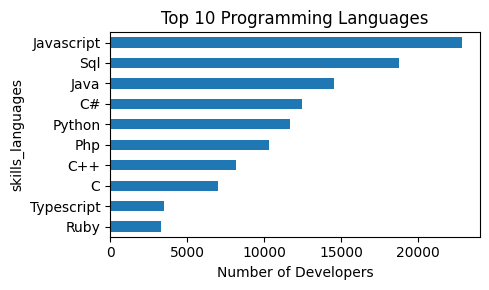

In [242]:
plt.figure(figsize=(5, 3))
top_languages.plot(kind='barh')
plt.xlabel('Number of Developers')
plt.title('Top 10 Programming Languages')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('top_languages.png', dpi=150)
plt.show()

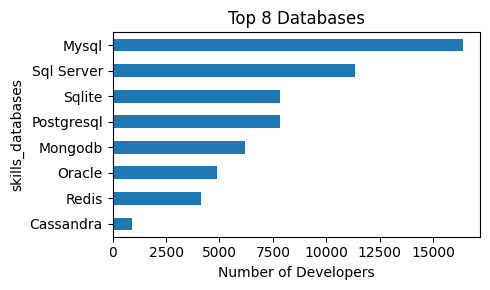

In [241]:
plt.figure(figsize=(5, 3))
top_databases.plot(kind='barh')
plt.xlabel('Number of Developers')
plt.title('Top 8 Databases')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('top_databases.png', dpi=150)
plt.show()

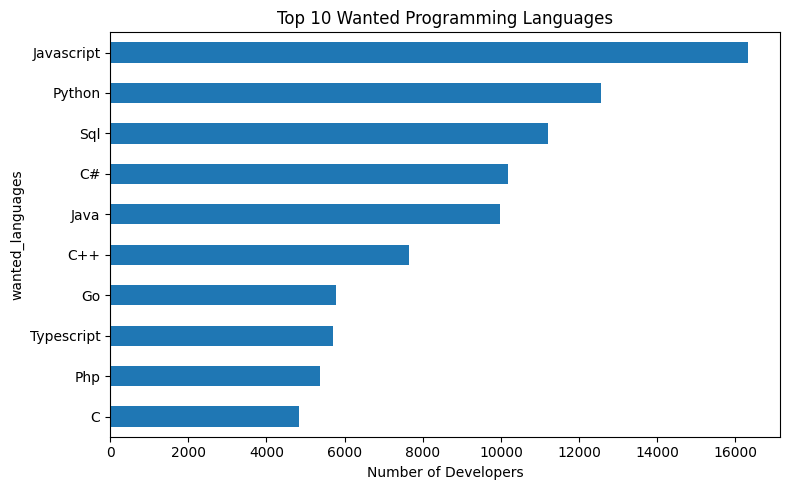

In [236]:
plt.figure(figsize=(8, 5))
top_wanted.plot(kind='barh')
plt.xlabel('Number of Developers')
plt.title('Top 10 Wanted Programming Languages')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('top_wanted.png', dpi=150)
plt.show()

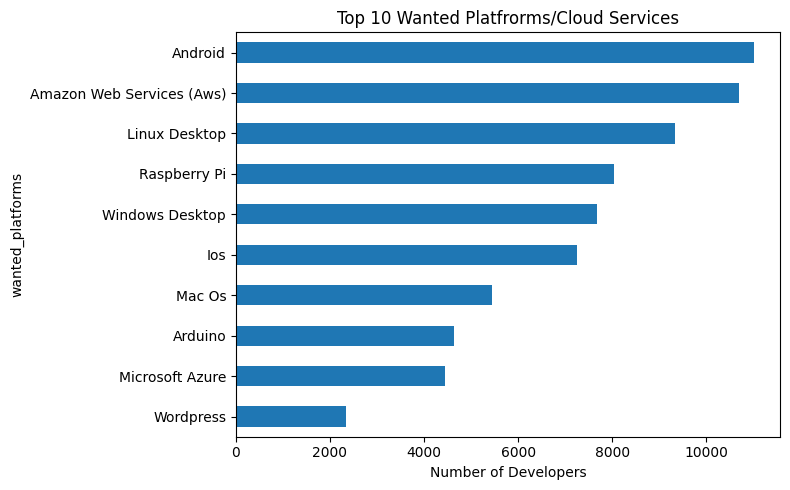

In [237]:
plt.figure(figsize=(8, 5))
top_platforms.plot(kind='barh')
plt.xlabel('Number of Developers')
plt.title('Top 10 Wanted Platfrorms/Cloud Services')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('top_platforms.png', dpi=150)
plt.show()

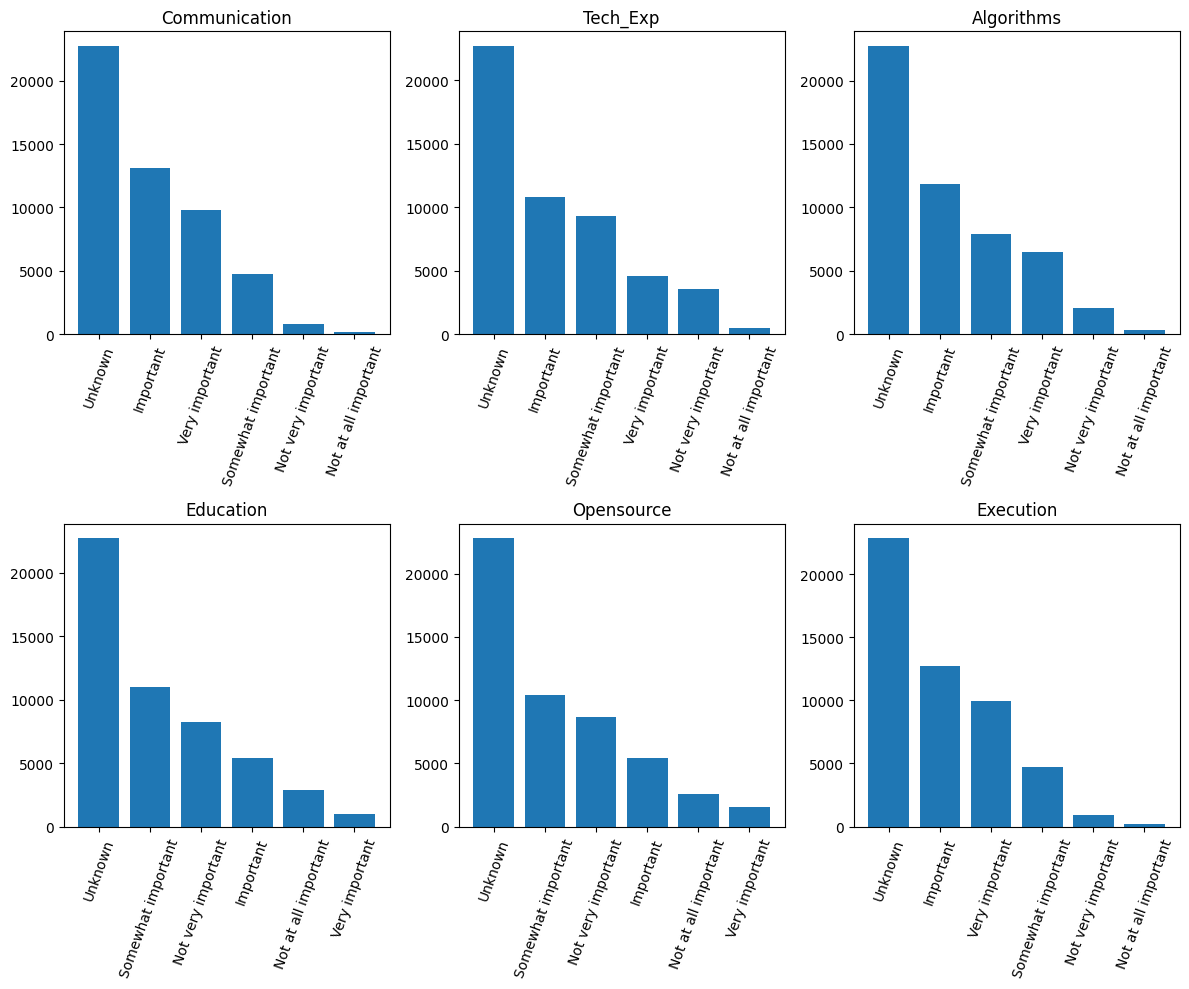

In [159]:
hiring_cols = ['hiring_communication_importance', 'hiring_tech_exp_importance', 'hiring_algorithms_importance', 
               'hiring_education_importance', 'hiring_opensource_importance', 'hiring_execution_importance']

fig, axes = plt.subplots(2, 3, figsize=(12, 10))
axes = axes.flatten()

for i, col in enumerate(hiring_cols):
    counts = df_clean[col].value_counts()
    axes[i].bar(counts.index, counts.values)
    axes[i].set_title(col.replace('hiring_', '').replace('_importance', '').title())
    axes[i].tick_params(axis='x', rotation=70)

plt.tight_layout()
plt.savefig('hiring_priorities.png', dpi=150)
plt.show()

In [153]:
df_clean['hiring_opensource_importance'].unique()

<StringArray>
[  'Somewhat important',            'Important',              'Unknown',
       'Very important', 'Not at all important',   'Not very important']
Length: 6, dtype: str

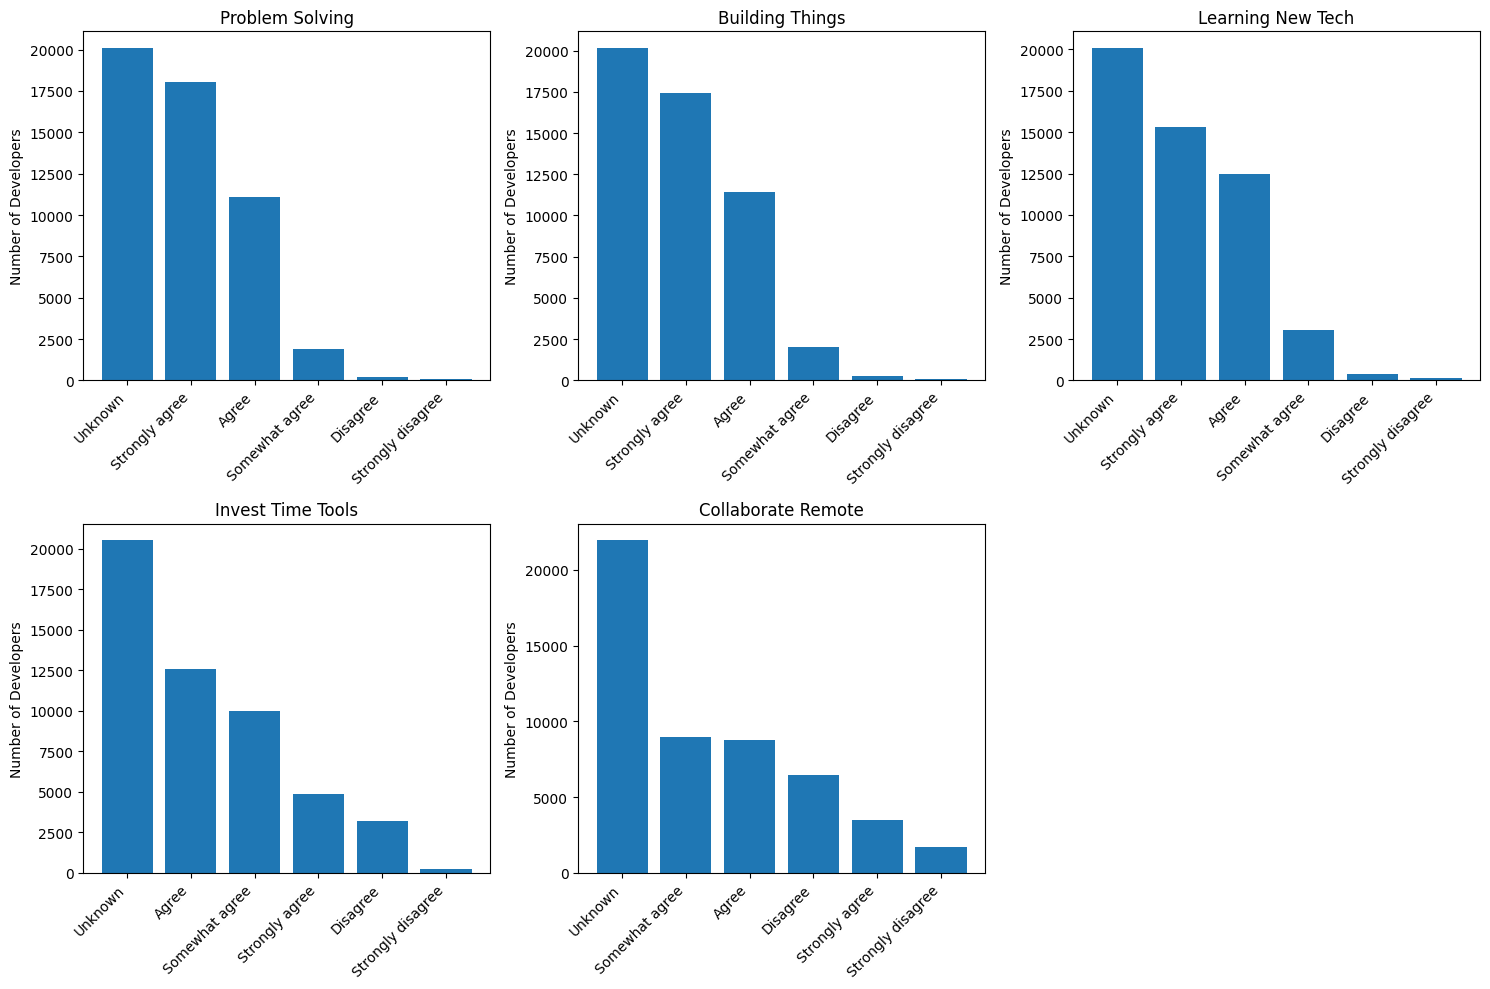

In [105]:
soft_skills = ['problem_solving', 'building_things', 'learning_new_tech', 
               'invest_time_tools', 'collaborate_remote']

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for i, skill in enumerate(soft_skills):
    counts = df_clean[skill].value_counts()

    axes[i].bar(range(len(counts)), counts.values)
    axes[i].set_xticks(range(len(counts)))
    axes[i].set_xticklabels(counts.index, rotation=45, ha='right')
    axes[i].set_title(skill.replace('_', ' ').title())
    axes[i].set_ylabel('Number of Developers')

axes[5].set_visible(False)

plt.tight_layout()
plt.savefig('soft_skills.png', dpi=150)
plt.show()

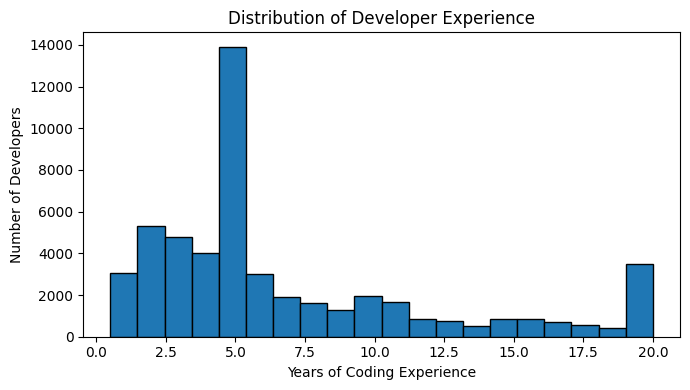

In [164]:
plt.figure(figsize=(7, 4))
plt.hist(df_clean['years_coding_numeric'], bins=20, edgecolor='black')
plt.xlabel('Years of Coding Experience')
plt.ylabel('Number of Developers')
plt.title('Distribution of Developer Experience')
plt.tight_layout()
plt.savefig('experience_distribution.png', dpi=150)
plt.show()

In [106]:
top_countries = df_clean['country'].value_counts().head(5)
print(top_countries)

country
United States     11455
India              5197
United Kingdom     4395
Germany            4143
Canada             2233
Name: count, dtype: int64


In [175]:
df_clean['job_title'].unique()

<StringArray>
[                                                                                                                                                                                                      'Not specified',
                                                                                                                                                                                                               'Other',
                                                                                                                                              'Mobile developer; Graphics programming; Desktop applications developer',
                                                                                                                                                                                                       'Web developer',
                                                                                                                          

In [209]:
from collections import Counter

# Get all job titles (excluding Not specified)
job_titles = df_clean[df_clean['job_title'] != 'Not specified']['job_title'].dropna()

# Split into words and count frequency
all_words = []
for title in job_titles:
    # Split by spaces and common separators
    words = str(title).lower().replace(';', ' ').replace('/', ' ').split()
    all_words.extend(words)

# Count word frequencies
word_counts = Counter(all_words)

# Show top 30 most common words
print("📊 MOST COMMON WORDS IN JOB TITLES:")
for word, count in word_counts.most_common(30):
    print(f"   {word:14}: {count}")

📊 MOST COMMON WORDS IN JOB TITLES:
   developer     : 52439
   web           : 26235
   applications  : 13787
   desktop       : 10435
   administrator : 9278
   mobile        : 8326
   specialist    : 5394
   database      : 5192
   with          : 4091
   a             : 4091
   statistics    : 4091
   or            : 4091
   mathematics   : 4091
   background    : 4091
   systems       : 4086
   devops        : 4015
   embedded      : 3352
   devices       : 3352
   data          : 3045
   scientist     : 3045
   other         : 2694
   graphics      : 1731
   programming   : 1731
   graphic       : 1426
   designer      : 1426
   machine       : 1379
   learning      : 1379
   quality       : 1252
   assurance     : 1252
   engineer      : 1252


In [177]:
# Create mapping based on actual keywords found
job_keywords = {
    'Web Developer': ['web'],
    'Desktop Developer': ['desktop', 'desktop applications'],
    'Mobile Developer': ['mobile'],
    'Database Administrator': ['database', 'administrator', 'dba'],
    'Systems Administrator': ['systems', 'system admin'],
    'DevOps Engineer': ['devops'],
    'Embedded Developer': ['embedded', 'devices'],
    'Data Scientist': ['data scientist', 'statistics', 'mathematics'],
    'Machine Learning': ['machine learning', 'ml'],
    'Graphics Developer': ['graphics', 'graphic', 'programming'],
    'Graphic Designer': ['graphic designer'],
    'QA Engineer': ['quality', 'assurance', 'qa'],
    'Other': []
}

def extract_job_category(job_title):
    if pd.isna(job_title) or job_title == 'Not specified':
        return 'Not specified'
    
    job_lower = str(job_title).lower()
    
    for category, keywords in job_keywords.items():
        for keyword in keywords:
            if keyword in job_lower:
                return category
    
    return 'Other'

# Apply
df_clean['job_category'] = df_clean['job_title'].apply(extract_job_category)

# Check distribution
print("📊 JOB CATEGORY DISTRIBUTION:")
print(df_clean['job_category'].value_counts())

📊 JOB CATEGORY DISTRIBUTION:
job_category
Web Developer             26235
Not specified             15267
Desktop Developer          3626
Mobile Developer           1983
Data Scientist             1175
Other                      1174
Embedded Developer          856
Database Administrator      504
DevOps Engineer             326
QA Engineer                 109
Graphics Developer           78
Machine Learning             59
Name: count, dtype: int64


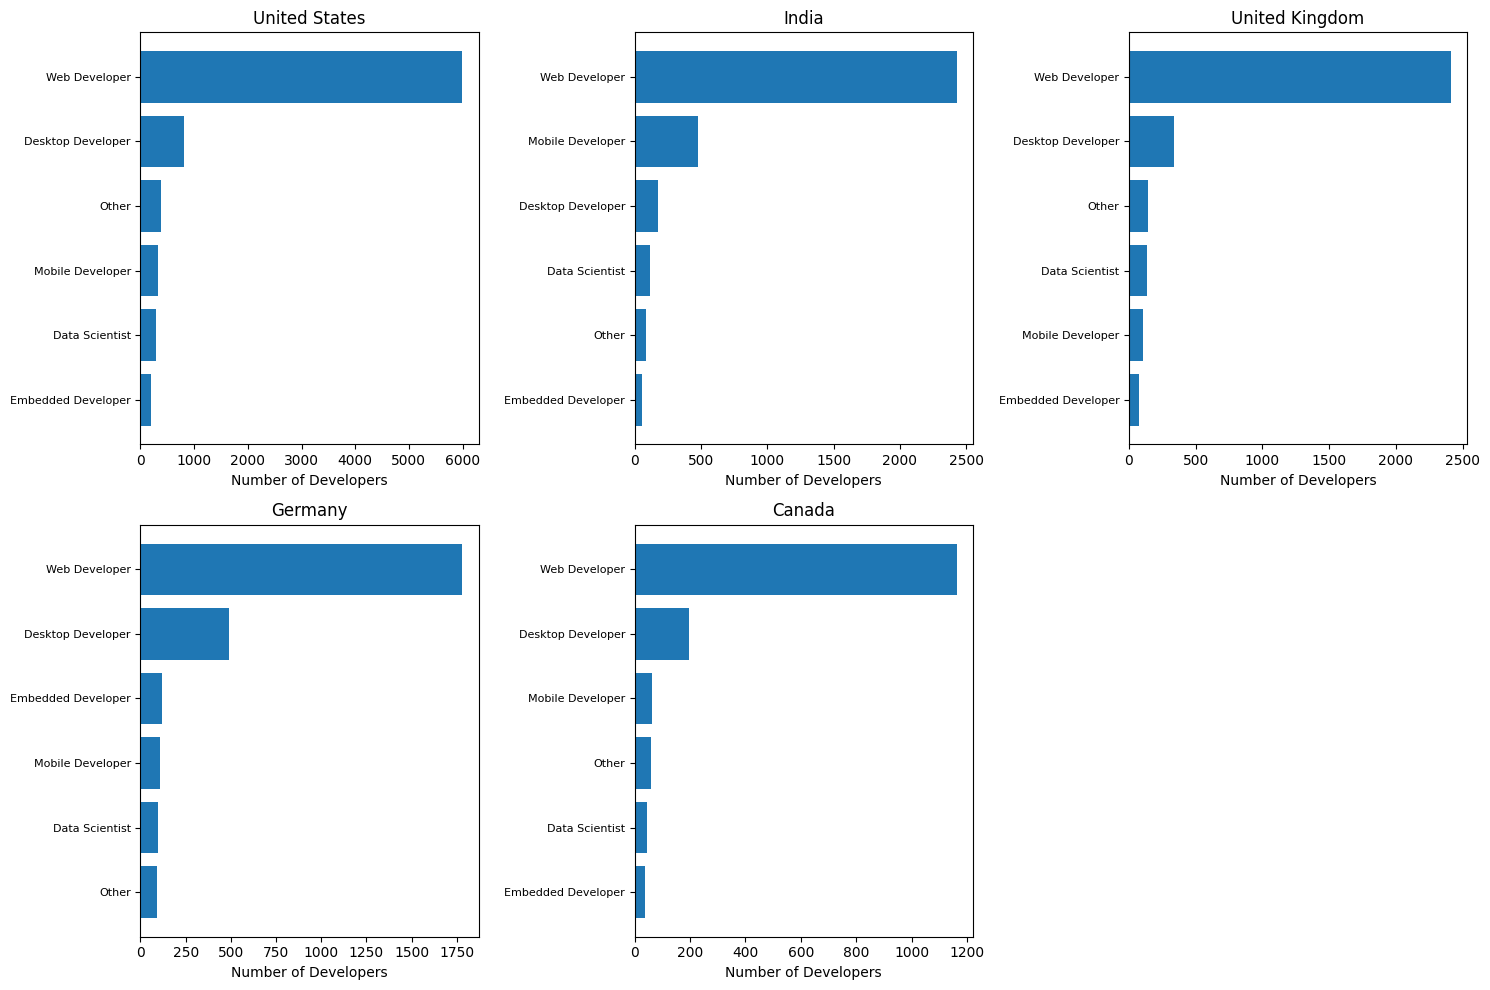

In [179]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for i, country in enumerate(top_countries):
    country_data = df_clean[df_clean['country'] == country]
    country_data = country_data[country_data['job_category'] != 'Not specified']
    
    top_cats = country_data['job_category'].value_counts().head(6)
    
    axes[i].barh(range(len(top_cats)), top_cats.values)
    axes[i].set_yticks(range(len(top_cats)))
    axes[i].set_yticklabels(top_cats.index, fontsize=8)
    axes[i].set_xlabel('Number of Developers')
    axes[i].set_title(f'{country}')
    axes[i].invert_yaxis()

# Hide unused subplot
if len(top_countries) < 6:
    axes[5].set_visible(False)

plt.tight_layout()
plt.savefig('job_categories_by_country.png', dpi=150)
plt.show()

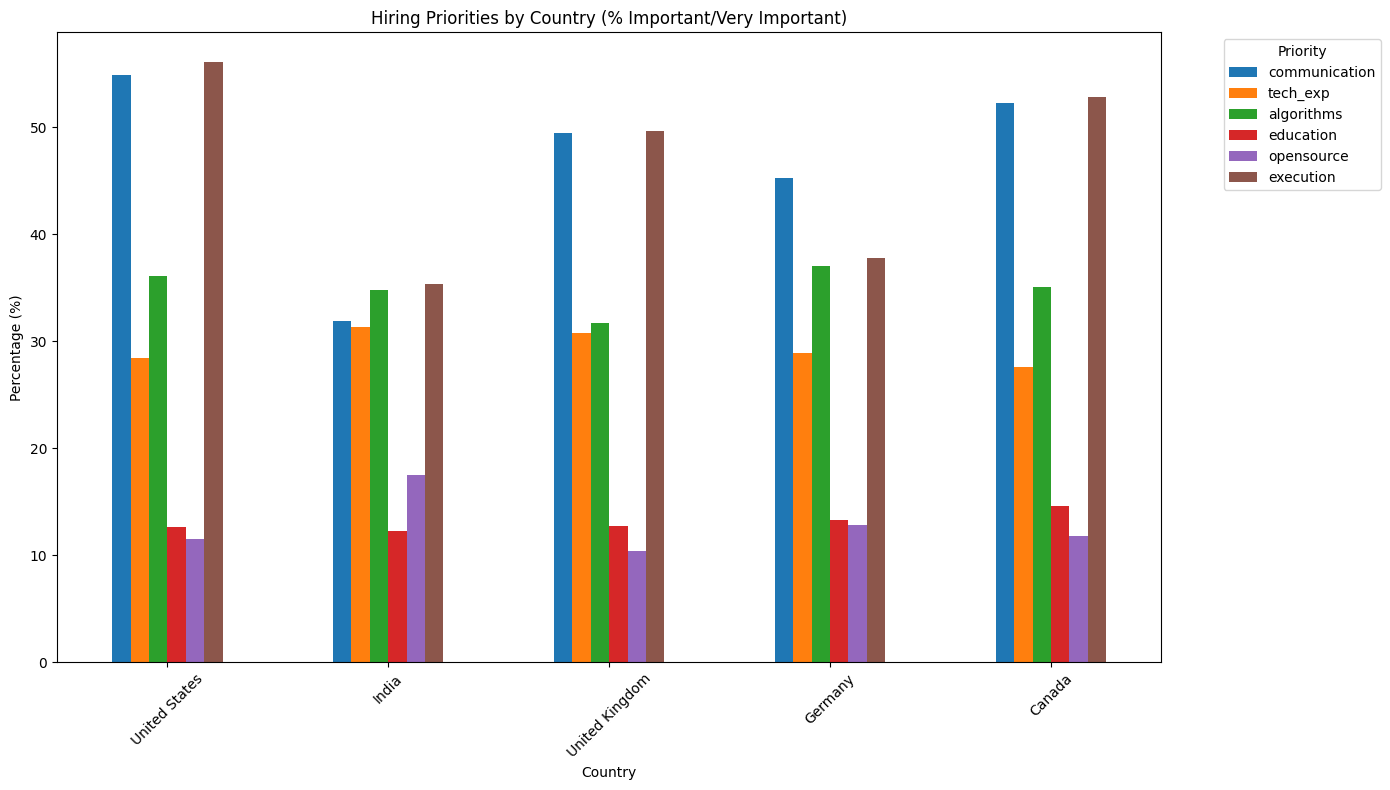

In [185]:
hiring_comparison = {}

for country in top_countries:
    country_data = df_clean[df_clean['country'] == country]
    hiring_comparison[country] = {}
    
    for col in hiring_cols:
        counts = country_data[col].value_counts()

        important_pct = (counts.get('Important', 0) + counts.get('Very important', 0)) / len(country_data) * 100
        hiring_comparison[country][col.replace('hiring_', '').replace('_importance', '')] = important_pct

hiring_df = pd.DataFrame(hiring_comparison).T

fig, ax = plt.subplots(figsize=(14, 8))
hiring_df.plot(kind='bar', ax=ax)
plt.xlabel('Country')
plt.ylabel('Percentage (%)')
plt.title('Hiring Priorities by Country (% Important/Very Important)')
plt.legend(title='Priority', bbox_to_anchor=(1.05, 1))
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('hiring_by_country.png', dpi=150)
plt.show()

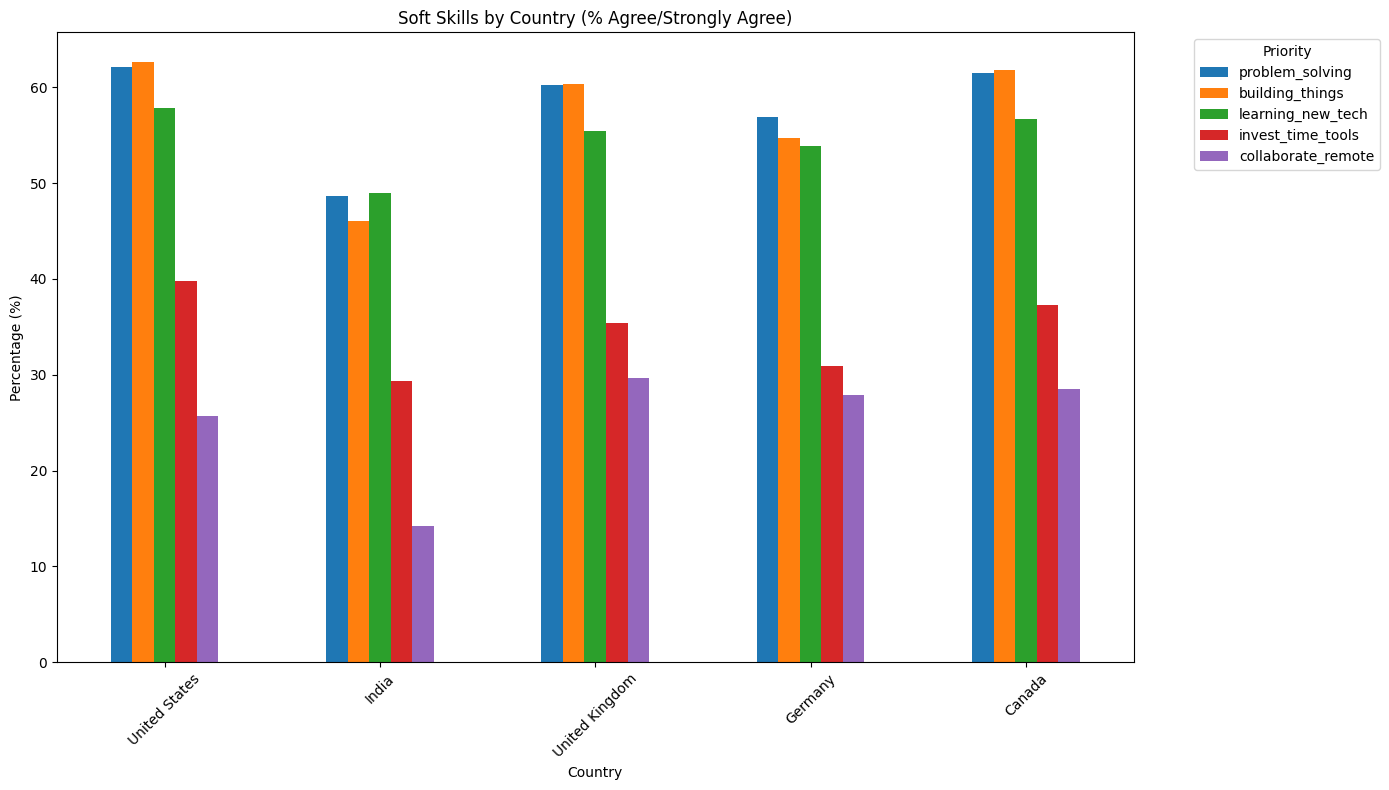

In [243]:
softskills_comparison = {}

for country in top_countries:
    country_data = df_clean[df_clean['country'] == country]
    softskills_comparison[country] = {}
    
    for col in soft_skills:
        counts = country_data[col].value_counts()

        important_pct = (counts.get('Strongly agree', 0) + counts.get('Agree', 0)) / len(country_data) * 100
        softskills_comparison[country][col]= important_pct

soft_df = pd.DataFrame(softskills_comparison).T

fig, ax = plt.subplots(figsize=(14, 8))
soft_df.plot(kind='bar', ax=ax)
plt.xlabel('Country')
plt.ylabel('Percentage (%)')
plt.title('Soft Skills by Country (% Agree/Strongly Agree)')
plt.legend(title='Priority', bbox_to_anchor=(1.05, 1))
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('soft_by_country.png', dpi=150)
plt.show()

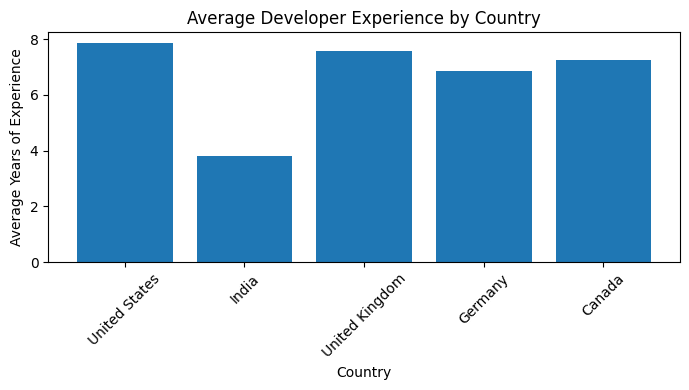


📊 AVERAGE EXPERIENCE BY COUNTRY:
   United States: 7.9 years
   India: 3.8 years
   United Kingdom: 7.6 years
   Germany: 6.9 years
   Canada: 7.2 years


In [199]:
# Compare experience across top countries
top_countries = df_clean['country'].value_counts().head(5).index

exp_by_country = {}
for country in top_countries:
    country_data = df_clean[df_clean['country'] == country]
    exp_by_country[country] = country_data['years_coding_numeric'].mean()

# Plot
plt.figure(figsize=(7, 4))
plt.bar(exp_by_country.keys(), exp_by_country.values())
plt.xlabel('Country')
plt.ylabel('Average Years of Experience')
plt.title('Average Developer Experience by Country')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('experience_by_country.png', dpi=150)
plt.show()

print("\n📊 AVERAGE EXPERIENCE BY COUNTRY:")
for country, avg_exp in exp_by_country.items():
    print(f"   {country}: {avg_exp:.1f} years")

In [250]:
for country in top_countries:
    country_data = df_clean[df_clean['country'] == country]
    country_data = country_data[country_data['skills_languages'] != '']
    
    skills = (country_data['skills_languages']
            .str.split(';')
            .explode()
            .str.strip()      
            .str.title()      
            .value_counts()
            .head(5))
    
    print(f"\n{country} TOP SKILLS:")
    for skill, count in skills.items():
        print(f"{skill:14}: {count}")


United States TOP SKILLS:
Javascript    : 5699
Sql           : 4589
Python        : 3348
Java          : 3191
C#            : 3100

India TOP SKILLS:
Javascript    : 1580
Java          : 1378
Sql           : 1373
Php           : 885
C             : 817

United Kingdom TOP SKILLS:
Javascript    : 2214
Sql           : 1849
C#            : 1386
Python        : 1038
Java          : 940

Germany TOP SKILLS:
Javascript    : 1770
Java          : 1458
Sql           : 1450
C#            : 953
Python        : 947

Canada TOP SKILLS:
Javascript    : 1104
Sql           : 872
C#            : 647
Python        : 620
Java          : 613


In [248]:
for country in top_countries:
    country_data = df_clean[df_clean['country'] == country]
    country_data = country_data[country_data['wanted_languages'] != '']
    
    want = (country_data['wanted_languages']
            .str.split(';')
            .explode()
            .value_counts()
            .head(5))
    
    print(f"\n{country} WANTS TO LEARN:")
    for skill, count in want.items():
        print(f"{skill:14}: {count}")


United States WANTS TO LEARN:
Javascript    : 4034
Python        : 3346
Sql           : 2785
C#            : 2610
Java          : 2094

India WANTS TO LEARN:
Javascript    : 1298
Python        : 1110
Java          : 1068
Sql           : 908
Php           : 528

United Kingdom WANTS TO LEARN:
Javascript    : 1504
C#            : 1170
Sql           : 1054
Python        : 1035
Java          : 683

Germany WANTS TO LEARN:
Javascript    : 1158
Python        : 916
Java          : 882
Sql           : 855
C#            : 765

Canada WANTS TO LEARN:
Javascript    : 802
Python        : 615
Sql           : 545
C#            : 521
Java          : 375


In [263]:
def get_top_values_by_country(df, country, column_name, n=5):
    """Get top n values for a specific country"""
    country_data = df[df['country'] == country]
    return (country_data[column_name]
            .str.split(';')
            .explode()
            .str.strip()
            .str.title()
            .dropna()
            .pipe(lambda x: x[x != ''])
            .value_counts()
            .head(n))

In [272]:
print("\n" + "="*80)
print("📊 JOB MARKET INTELLIGENCE PLATFORM - KEY INSIGHTS")
print("="*80)

# 1. TOP LANGUAGE GLOBALLY
print("\n💻 1. TOP LANGUAGE GLOBALLY:")
print(f"   → {top_languages.index[0]} ({top_languages.iloc[0]:,} developers)")

# 2. TOP LANGUAGE FOR TOP 5 COUNTRIES
print("\n🌍 2. TOP LANGUAGE FOR TOP 5 COUNTRIES:")
top_countries = df_clean['country'].value_counts().head(5).index
for country in top_countries:
    top_skill = get_top_values_by_country(df_clean, country, 'skills_languages', 1)
    if len(top_skill) > 0:
        print(f"   → {country}: {top_skill.index[0]}")

# 3. TOP WANTED LANGUAGE GLOBALLY
print("\n📈 3. TOP WANTED LANGUAGE GLOBALLY:")
print(f"   → {top_wanted.index[0]} ({top_wanted.iloc[0]:,} want to learn)")

# 4. TOP WANTED LANGUAGE FOR TOP 5 COUNTRIES
print("\n🎯 4. TOP WANTED LANGUAGE FOR TOP 5 COUNTRIES:")
for country in top_countries:
    top_wanted_country = get_top_values_by_country(df_clean, country, 'wanted_languages', 1)
    if len(top_wanted_country) > 0:
        print(f"   → {country}: {top_wanted_country.index[0]}")

# 5. TOP GAP LANGUAGE GLOBALLY 
print("\n📊 5. TOP GAP LANGUAGE GLOBALLY:")
all_have = (df_clean['skills_languages']
            .str.split(';')
            .explode()
            .str.strip()
            .str.title()
            .value_counts())
all_want = (df_clean['wanted_languages']
            .str.split(';')
            .explode()
            .str.strip()
            .str.title()
            .value_counts())

top_gap_skill = None
top_gap_value = 0
for skill in all_want.index:
    if skill != '':
        gap = all_want[skill] - all_have.get(skill, 0)
        if gap > top_gap_value:
            top_gap_value = gap
            top_gap_skill = skill

print(f"   → {top_gap_skill}: wanted by {all_want[top_gap_skill]:,}, have by {all_have.get(top_gap_skill, 0):,}, gap = {top_gap_value:,}")

# 6. TOP JOB TITLE GLOBALLY
print("\n💼 6. TOP JOB TITLE GLOBALLY:")
top_jobs_global = df_clean['job_title'].value_counts()
top_jobs_global = top_jobs_global[top_jobs_global.index != 'Not specified']
print(f"   → {top_jobs_global.index[0]} ({top_jobs_global.iloc[0]:,} developers)")

# 7. TOP JOB TITLE FOR TOP 5 COUNTRIES
print("\n🏢 7. TOP JOB TITLE FOR TOP 5 COUNTRIES:")
for country in top_countries:
    country_data = df_clean[df_clean['country'] == country]
    country_jobs = country_data['job_title'].value_counts()
    country_jobs = country_jobs[country_jobs.index != 'Not specified']
    if len(country_jobs) > 0:
        print(f"   → {country}: {country_jobs.index[0]}")

# 8. TOP HIRING PRIORITY FOR TOP 5 COUNTRIES
print("\n⭐ 8. TOP HIRING PRIORITY FOR TOP 5 COUNTRIES:")
hiring_cols = ['hiring_communication_importance', 'hiring_tech_exp_importance', 
               'hiring_algorithms_importance', 'hiring_education_importance']
for country in top_countries:
    country_data = df_clean[df_clean['country'] == country]
    best_hiring = None
    best_pct = 0
    for col in hiring_cols:
        pct = ((country_data[col] == 'Important') | (country_data[col] == 'Very important')).mean() * 100
        if pct > best_pct:
            best_pct = pct
            best_hiring = col.replace('hiring_', '').replace('_importance', '')
    print(f"   → {country}: {best_hiring} ({best_pct:.0f}%)")

# 9. TOP SOFT SKILL FOR TOP 5 COUNTRIES
print("\n💡 9. TOP SOFT SKILLS FOR TOP 5 COUNTRIES:")
soft_skills = ['problem_solving', 'learning_new_tech', 'building_things', 'invest_time_tools', 'collaborate_remote']
for country in top_countries:
    country_data = df_clean[df_clean['country'] == country]
    best_soft = None
    best_pct = 0
    for skill in soft_skills:
        pct = ((country_data[skill] == 'Agree') | (country_data[skill] == 'Strongly agree')).mean() * 100
        if pct > best_pct:
            best_pct = pct
            best_soft = skill.replace('_', ' ').title()
    print(f"   → {country}: {best_soft} ({best_pct:.0f}%)")

# 10. AVERAGE YEARS OF CODING FOR TOP 5 COUNTRIES
print("\n📅 10. AVERAGE YEARS OF CODING FOR TOP 5 COUNTRIES:")
for country in top_countries:
    country_data = df_clean[df_clean['country'] == country]
    avg_years = country_data['years_coding_numeric'].mean()
    print(f"   → {country}: {avg_years:.1f} years")

print("\n" + "="*80)
print("✅ EDA COMPLETE")
print("="*80)


📊 JOB MARKET INTELLIGENCE PLATFORM - KEY INSIGHTS

💻 1. TOP LANGUAGE GLOBALLY:
   → Javascript (22,875 developers)

🌍 2. TOP LANGUAGE FOR TOP 5 COUNTRIES:
   → United States: Javascript
   → India: Javascript
   → United Kingdom: Javascript
   → Germany: Javascript
   → Canada: Javascript

📈 3. TOP WANTED LANGUAGE GLOBALLY:
   → Javascript (16,327 want to learn)

🎯 4. TOP WANTED LANGUAGE FOR TOP 5 COUNTRIES:
   → United States: Javascript
   → India: Javascript
   → United Kingdom: Javascript
   → Germany: Javascript
   → Canada: Javascript

📊 5. TOP GAP LANGUAGE GLOBALLY:
   → Go: wanted by 5,770, have by 1,557, gap = 4,213

💼 6. TOP JOB TITLE GLOBALLY:
   → Web developer (10,683 developers)

🏢 7. TOP JOB TITLE FOR TOP 5 COUNTRIES:
   → United States: Web developer
   → India: Web developer
   → United Kingdom: Web developer
   → Germany: Web developer
   → Canada: Web developer

⭐ 8. TOP HIRING PRIORITY FOR TOP 5 COUNTRIES:
   → United States: communication (55%)
   → India: algorit